In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_air_passengers
from src.feature_engineering import create_lag_features, get_feature_target_columns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

In [2]:
df = load_air_passengers()
df_features = create_lag_features(df, n_lags=12)
feature_cols, target_col = get_feature_target_columns(df_features)

X = df_features[feature_cols].values
y = df_features[target_col].values

print(f"Design matrix X: shape {X.shape}")
print(f"Target vector y: shape {y.shape}")

Design matrix X: shape (132, 12)
Target vector y: shape (132,)


## 1. Closed-Form Solution of Linear Regression

The ordinary least squares (OLS) problem is:

$$\hat{\beta} = \arg\min_{\beta} \|X\beta - y\|_2^2$$

Setting the gradient to zero yields the **normal equation**:

$$X^T X \hat{\beta} = X^T y$$

If $X^T X$ is invertible, the solution is:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

Below we implement this manually in NumPy and compare against scikit-learn.

In [4]:
from sklearn.linear_model import LinearRegression

# --- Manual closed-form solution ---
X_with_bias = np.c_[np.ones(X.shape[0]), X]  # add intercept column
XTX = X_with_bias.T @ X_with_bias
XTy = X_with_bias.T @ y
beta_manual = np.linalg.inv(XTX) @ XTy

print("Manual closed-form solution:")
print(f"  Intercept: {beta_manual[0]:.4f}")
print(f"  Coefficients (first 5): {beta_manual[1:6]}")

# --- scikit-learn solution ---
lr = LinearRegression().fit(X, y)
print("\nscikit-learn solution:")
print(f"  Intercept: {lr.intercept_:.4f}")
print(f"  Coefficients (first 5): {lr.coef_[:5]}")

Manual closed-form solution:
  Intercept: 9.4369
  Coefficients (first 5): [ 0.4437 -0.2716  0.1944 -0.2153  0.2336]

scikit-learn solution:
  Intercept: 9.4369
  Coefficients (first 5): [ 0.4437 -0.2716  0.1944 -0.2153  0.2336]


In [5]:
beta_sklearn = np.r_[lr.intercept_, lr.coef_]
difference = np.abs(beta_manual - beta_sklearn)

print(f"Maximum absolute difference: {difference.max():.2e}")
print(f"All differences < 1e-10: {np.allclose(beta_manual, beta_sklearn)}")

Maximum absolute difference: 4.88e-12
All differences < 1e-10: True


## 2. Eigendecomposition of the Autocovariance Matrix

For a stationary time series, the **autocovariance matrix** $\Sigma$ is:

$$\Sigma_{ij} = \text{Cov}(x_t, x_{t+|i-j|})$$

This matrix is **symmetric positive semi-definite**, so it admits an
eigendecomposition:

$$\Sigma = Q \Lambda Q^T$$

where $Q$ contains orthonormal eigenvectors and $\Lambda$ is diagonal
with non-negative eigenvalues. The eigenvalues reveal the **dominant
directions of variation** in the series.

In [6]:
# Compute autocovariance matrix using lagged versions of the series
series = df['value'].values
n_lags = 12
n = len(series)

# Build lagged matrix: each column is the series shifted by k
lagged = np.column_stack([series[k:n - n_lags + k] for k in range(n_lags)])
print(f"Lagged matrix shape: {lagged.shape}")

# Covariance matrix (unbiased)
cov_matrix = np.cov(lagged, rowvar=False)
print(f"Covariance matrix shape: {cov_matrix.shape}")

# Eigendecomposition (symmetric matrix)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigh returns ascending order; sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"\nEigenvalues (descending):")
print(eigenvalues)
print(f"\nSum of eigenvalues: {eigenvalues.sum():.2f}")
print(f"Variance of original series: {np.var(series, ddof=1):.2f}")

Lagged matrix shape: (132, 12)
Covariance matrix shape: (12, 12)

Eigenvalues (descending):
[125766.764    8015.9417   7633.502    2148.0839   2067.1949    397.9426
    378.7716    256.5484    231.7564    174.9804    173.2176     29.3192]

Sum of eigenvalues: 147274.02
Variance of original series: 14391.92


In [7]:
# Verify symmetry
is_symmetric = np.allclose(cov_matrix, cov_matrix.T)
print(f"Covariance matrix symmetric: {is_symmetric}")

# Verify positive semi-definiteness (all eigenvalues >= 0)
is_psd = np.all(eigenvalues >= -1e-10)
print(f"Positive semi-definite (all eigenvalues >= 0): {is_psd}")

# Condition number
cond = eigenvalues[0] / eigenvalues[-1]
print(f"Condition number: {cond:.2f}")

# Trace identity: trace(Sigma) = sum of eigenvalues
print(f"\ntrace(cov_matrix) = {np.trace(cov_matrix):.4f}")
print(f"sum(eigenvalues)  = {eigenvalues.sum():.4f}")
print(f"Trace equals sum of eigenvalues: {np.allclose(np.trace(cov_matrix), eigenvalues.sum())}")

Covariance matrix symmetric: True
Positive semi-definite (all eigenvalues >= 0): True
Condition number: 4289.57

trace(cov_matrix) = 147274.0226
sum(eigenvalues)  = 147274.0226
Trace equals sum of eigenvalues: True


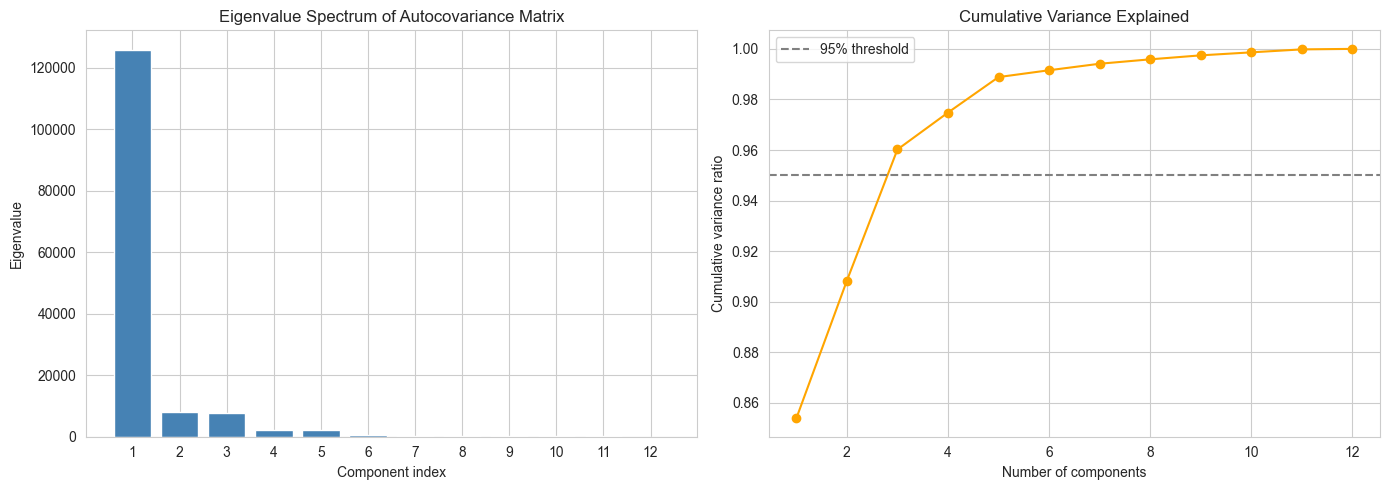

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eigenvalue spectrum
axes[0].bar(range(1, len(eigenvalues) + 1), eigenvalues, color='steelblue')
axes[0].set_title('Eigenvalue Spectrum of Autocovariance Matrix')
axes[0].set_xlabel('Component index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_xticks(range(1, len(eigenvalues) + 1))

# Cumulative variance explained
cumvar = np.cumsum(eigenvalues) / eigenvalues.sum()
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='orange')
axes[1].axhline(0.95, color='gray', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/07_eigenvalue_spectrum.png', dpi=150)
plt.show()

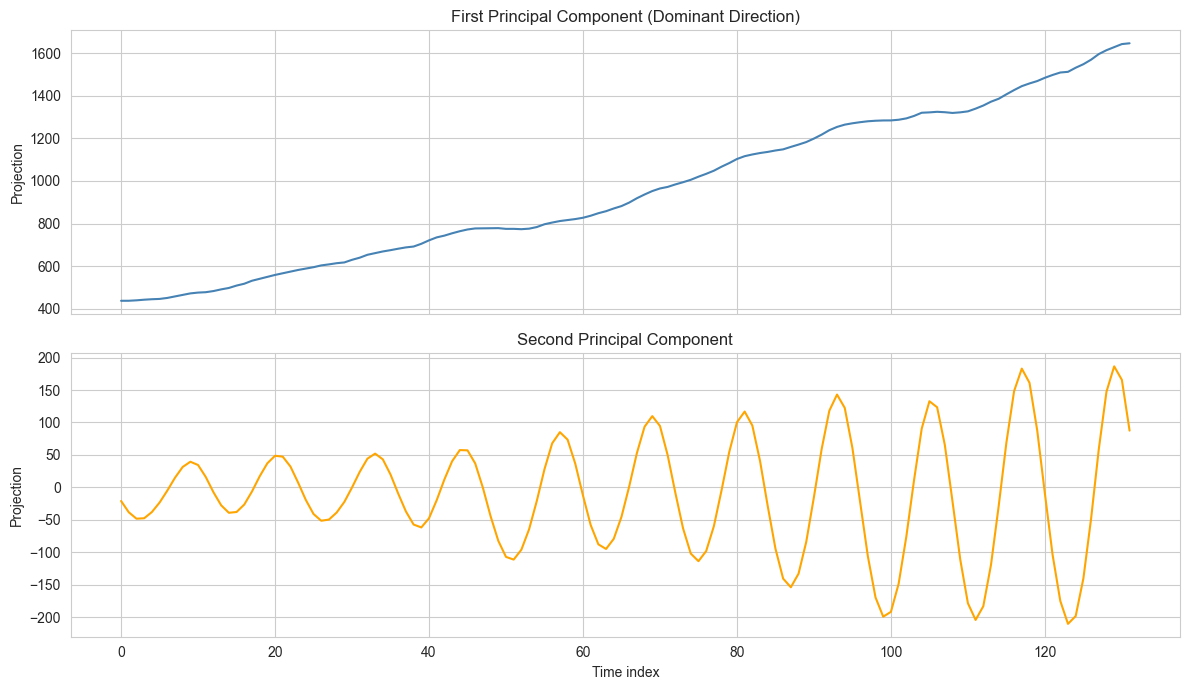

In [9]:
# Project the lagged data onto the top-2 eigenvectors
projected = lagged @ eigenvectors[:, :2]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(projected[:, 0], color='steelblue')
axes[0].set_title('First Principal Component (Dominant Direction)')
axes[0].set_ylabel('Projection')

axes[1].plot(projected[:, 1], color='orange')
axes[1].set_title('Second Principal Component')
axes[1].set_xlabel('Time index')
axes[1].set_ylabel('Projection')

plt.tight_layout()
plt.savefig('../results/figures/08_principal_components.png', dpi=150)
plt.show()

In [10]:
import json

math_results = {
    "closed_form_vs_sklearn_max_diff": float(difference.max()),
    "eigenvalues": [float(v) for v in eigenvalues],
    "cumulative_variance_ratio": [float(v) for v in cumvar],
    "condition_number": float(cond),
    "trace_matches_sum_eigenvalues": bool(np.allclose(np.trace(cov_matrix), eigenvalues.sum())),
}

with open('../results/math_results.json', 'w') as f:
    json.dump(math_results, f, indent=2)

print("Math results saved.")

Math results saved.


In [11]:
print("=" * 60)
print("Eigenvalues (descending):")
print("=" * 60)
for i, ev in enumerate(eigenvalues, 1):
    print(f"  PC{i:>2}: {ev:>10.4f}  ({ev / eigenvalues.sum() * 100:>5.2f}%)")

print("\n" + "=" * 60)
print("Cumulative variance explained:")
print("=" * 60)
for i, cv in enumerate(cumvar, 1):
    print(f"  Top {i:>2} components: {cv * 100:>6.2f}%")

print("\n" + "=" * 60)
print(f"Condition number: {cond:.2f}")
print(f"Trace == sum of eigenvalues: {np.allclose(np.trace(cov_matrix), eigenvalues.sum())}")

Eigenvalues (descending):
  PC 1: 125766.7640  (85.40%)
  PC 2:  8015.9417  ( 5.44%)
  PC 3:  7633.5020  ( 5.18%)
  PC 4:  2148.0839  ( 1.46%)
  PC 5:  2067.1949  ( 1.40%)
  PC 6:   397.9426  ( 0.27%)
  PC 7:   378.7716  ( 0.26%)
  PC 8:   256.5484  ( 0.17%)
  PC 9:   231.7564  ( 0.16%)
  PC10:   174.9804  ( 0.12%)
  PC11:   173.2176  ( 0.12%)
  PC12:    29.3192  ( 0.02%)

Cumulative variance explained:
  Top  1 components:  85.40%
  Top  2 components:  90.84%
  Top  3 components:  96.02%
  Top  4 components:  97.48%
  Top  5 components:  98.88%
  Top  6 components:  99.15%
  Top  7 components:  99.41%
  Top  8 components:  99.59%
  Top  9 components:  99.74%
  Top 10 components:  99.86%
  Top 11 components:  99.98%
  Top 12 components: 100.00%

Condition number: 4289.57
Trace == sum of eigenvalues: True


## Interpretation

The eigenvalue spectrum reveals the low-dimensional structure of the series:

| Component | Variance Explained | Cumulative |
|:---|:---|:---|
| PC1 | 85.40% | 85.40% |
| PC2 | 5.44% | 90.84% |
| PC3 | 5.18% | 96.02% |

- **PC1 (85.4%)** captures the dominant long-term trend.
- **PC2 and PC3** capture the annual seasonality.
- The top 3 components account for **96% of total variance**, indicating
  that the series is effectively low-dimensional.

The condition number of the autocovariance matrix is **4289.57**, reflecting
the high correlation between lag features — a common characteristic of
non-stationary time series. This motivates regularization techniques
(ridge, LASSO) and dimensionality reduction in downstream modeling.